
# One-point additions in a two-blob point cloud

This notebook illustrates the index-set API:

```python
pointcloud_similarity_index_sets(points, indices_X, indices_Y)
```

The master array `points` is stored once.  The two point clouds are just index sets into that array.  Here `X` is a fixed two-blob cloud and `Y` is the same cloud plus one extra point.

The three cases are:

1. an added point between the two blobs,
2. an added point inside one blob,
3. an added point far from both blobs.

For this particular setup, `X` is the base cloud and `Y` is `X` plus the candidate.  Therefore `X ∪ Y = Y`.  The score can be above or below 1 because the denominator changes when the added point makes the union easier or harder to connect.


In [1]:

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the module from the same directory as this notebook.
HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from pointcloud_similarity import pointcloud_similarity_index_sets, emst



## Construct the base cloud and the three candidate additions

The two base blobs are deliberately separated enough that their MST has one long inter-blob edge.  A point placed between the blobs can shorten that bottleneck substantially.


In [2]:

rng = np.random.default_rng(7)

n_per_blob = 25
blob_sep = 6.0
sigma = 0.32

left_center = np.array([-blob_sep / 2, 0.0])
right_center = np.array([blob_sep / 2, 0.0])

left = rng.normal(loc=left_center, scale=sigma, size=(n_per_blob, 2))
right = rng.normal(loc=right_center, scale=sigma, size=(n_per_blob, 2))
base = np.vstack([left, right])
base_idx = np.arange(len(base), dtype=np.int64)

candidate_points = {
    "bridge between blobs": np.array([0.0, 0.0]),
    "inside left blob": left_center + np.array([0.03, -0.02]),
    "far from all blobs": np.array([0.0, 7.5]),
}

candidate_names = list(candidate_points)
candidate_array = np.vstack([candidate_points[name] for name in candidate_names])
points = np.vstack([base, candidate_array])
candidate_indices = {
    name: len(base) + j for j, name in enumerate(candidate_names)
}

base_mst = emst(base, method="auto")
print(f"Base cloud size: {len(base)}")
print(f"Base connectivity threshold, max MST edge: {base_mst.max_edge:.3f}")


Base cloud size: 50
Base connectivity threshold, max MST edge: 5.027



## Compute the comparison for each candidate

Each call below uses the same master `points` array.  Only the index sets change.


In [3]:

results = {}
rows = []

for name, candidate_idx in candidate_indices.items():
    idx_X = base_idx
    idx_Y = np.r_[base_idx, candidate_idx]
    res = pointcloud_similarity_index_sets(points, idx_X, idx_Y, mst_method="auto")
    results[name] = res
    rows.append({
        "case": name,
        "s": res.s,
        "R": res.R,
        "I_X": res.I_X,
        "I_Y": res.I_Y,
        "I_union": res.I_union,
        "max_edge_X": res.mst_X.max_edge,
        "max_edge_Y": res.mst_Y.max_edge,
        "added_index": res.y_unique_index,
    })

summary = pd.DataFrame(rows).set_index("case")
display(summary.style.format({
    "s": "{:.4f}",
    "R": "{:.3f}",
    "I_X": "{:.3f}",
    "I_Y": "{:.3f}",
    "I_union": "{:.3f}",
    "max_edge_X": "{:.3f}",
    "max_edge_Y": "{:.3f}",
}))


,s,R,I_X,I_Y,I_union,max_edge_X,max_edge_Y,added_index
case,,,,,,,,
bridge between blobs,0.9926,5.027,17.342,17.472,17.472,5.027,2.613,50
inside left blob,0.9998,5.027,17.342,17.346,17.346,5.027,5.027,51
far from all blobs,0.7242,7.572,19.887,27.458,27.458,5.027,7.572,52



## Geometry and MST edges after adding the point

The faint line segments are MST edges for `Y = base + candidate`.  The added point is drawn with a star marker.


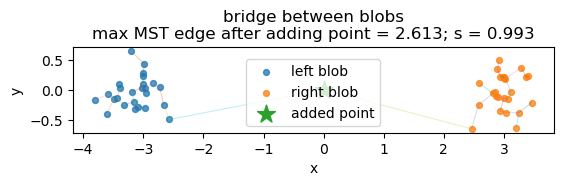

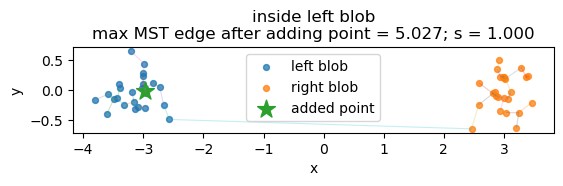

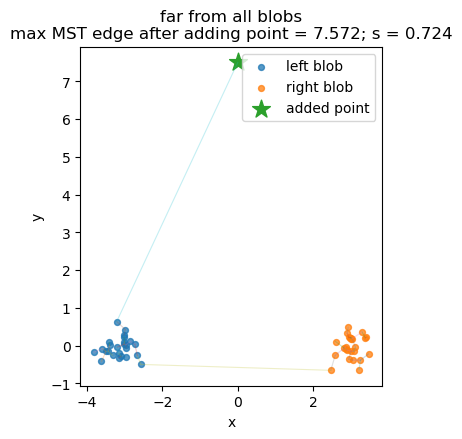

In [4]:

def draw_mst_edges(ax, local_points, mst, linewidth=0.8, alpha=0.25):
    for u, v in zip(mst.u, mst.v):
        p = local_points[int(u)]
        q = local_points[int(v)]
        ax.plot([p[0], q[0]], [p[1], q[1]], linewidth=linewidth, alpha=alpha)

for name, candidate_idx in candidate_indices.items():
    res = results[name]
    y_indices = np.r_[base_idx, candidate_idx]
    y_points = points[y_indices]

    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    draw_mst_edges(ax, y_points, res.mst_Y)
    ax.scatter(left[:, 0], left[:, 1], s=18, alpha=0.75, label="left blob")
    ax.scatter(right[:, 0], right[:, 1], s=18, alpha=0.75, label="right blob")
    ax.scatter(points[candidate_idx, 0], points[candidate_idx, 1], s=180, marker="*", label="added point")
    ax.set_title(f"{name}\nmax MST edge after adding point = {res.mst_Y.max_edge:.3f}; s = {res.s:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best")
    plt.show()



## Component-count curves

The integral `I(Z)` is the area under the component-count curve `C_r(Z)` from `r=0` to the shared cutoff `R`.


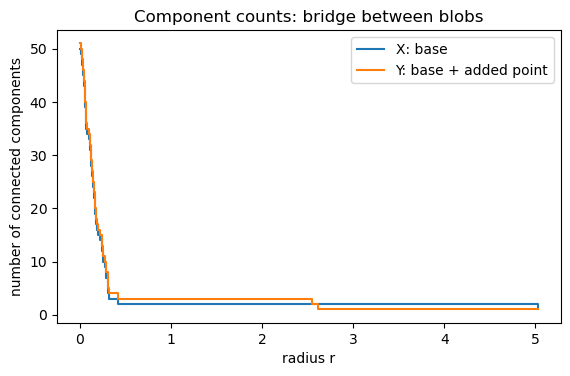

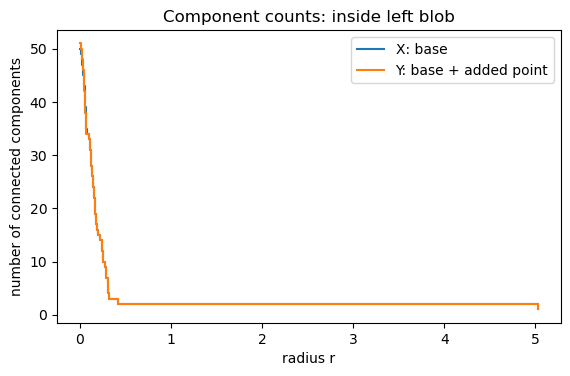

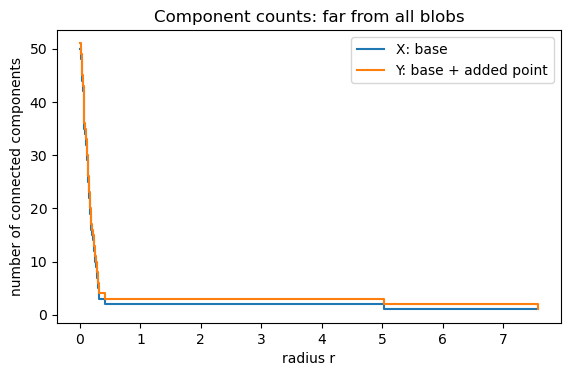

In [5]:

def component_count_step(mst, R):
    weights = np.sort(np.asarray(mst.w, dtype=float))
    x_values = [0.0]
    y_values = [mst.n]
    components = mst.n
    for w in weights:
        if w > R:
            break
        x_values.extend([float(w), float(w)])
        y_values.extend([components, components - 1])
        components -= 1
    x_values.append(float(R))
    y_values.append(components)
    return np.array(x_values), np.array(y_values)

for name, res in results.items():
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    x0, y0 = component_count_step(res.mst_X, res.R)
    x1, y1 = component_count_step(res.mst_Y, res.R)
    ax.step(x0, y0, where="post", label="X: base")
    ax.step(x1, y1, where="post", label="Y: base + added point")
    ax.set_title(f"Component counts: {name}")
    ax.set_xlabel("radius r")
    ax.set_ylabel("number of connected components")
    ax.legend(loc="best")
    plt.show()
